<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula02a_classificador_linear_bin%C3%A1rio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

cancer = load_breast_cancer()

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [37]:
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [40]:
corr = df.corr()
print(corr['target'].sort_values(ascending=True))

worst concave points      -0.793566
worst perimeter           -0.782914
mean concave points       -0.776614
worst radius              -0.776454
mean perimeter            -0.742636
worst area                -0.733825
mean radius               -0.730029
mean area                 -0.708984
mean concavity            -0.696360
worst concavity           -0.659610
mean compactness          -0.596534
worst compactness         -0.590998
radius error              -0.567134
perimeter error           -0.556141
area error                -0.548236
worst texture             -0.456903
worst smoothness          -0.421465
worst symmetry            -0.416294
mean texture              -0.415185
concave points error      -0.408042
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0

In [41]:
feat1 = corr.sort_values(ascending=True, by='target').index[0]
feat2 = corr.sort_values(ascending=True, by='target').index[1]
X = df[[feat1, feat2]].to_numpy()
y = df['target'].to_numpy()
print(X.shape)
print(y.shape)

(569, 2)
(569,)


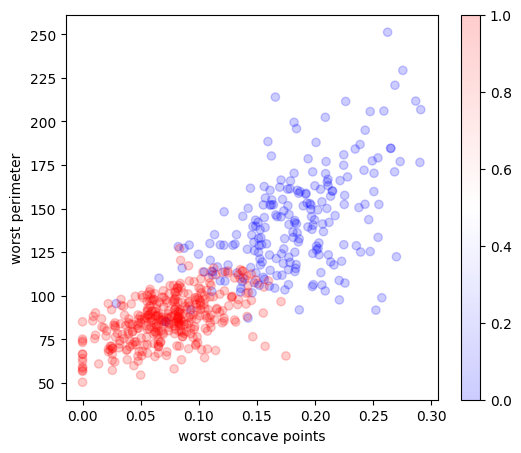

In [43]:
from matplotlib import pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(df[feat1], df[feat2], c=df['target'], cmap='bwr', alpha=0.2)
plt.colorbar()
plt.xlabel(feat1)
plt.ylabel(feat2)
plt.show()


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [111]:
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np
from sklearn.metrics import mean_squared_error

def include_bias(X):
  return np.c_[np.ones(len(X)), X]

class LinearRegressor(BaseEstimator, RegressorMixin):
  def fit(self, X, y):
    Xb = include_bias(X)
    self.w = np.linalg.pinv(Xb) @ y
    return self
  def predict(self, X):
    Xb = include_bias(X)
    y_pred = Xb @ self.w
    return y_pred

model = LinearRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(model.w)
print(mean_squared_error(y_test, y_pred))

[ 1.64045918 -3.47046964 -0.00574794]
0.06730149305538809


In [112]:
print(y_test[:6])
print(y_pred[:6])

[1 0 0 1 1 0]
[ 0.73611732  0.06600969  0.39711295  0.86961308  0.94754974 -0.34028414]


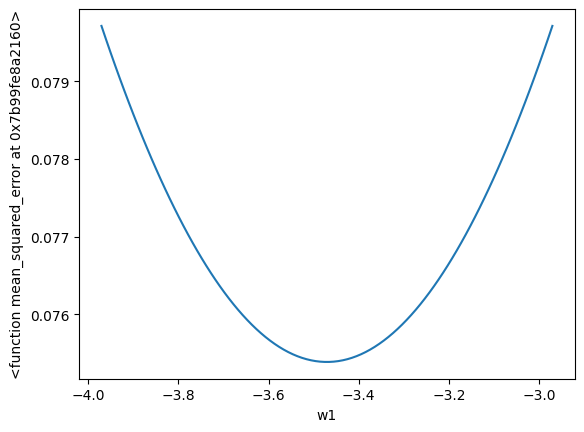

In [113]:
def plot_metric_by_coef(model, X, y, coef_idx=1, metric=mean_squared_error):
  coef_val = model.w[coef_idx]
  coefs = np.linspace(coef_val-0.5, coef_val+0.5, 100)
  metrics_vals = []
  for coef in coefs:
    model.w[coef_idx] = coef
    y_pred = model.predict(X)
    metrics_vals.append(metric(y, y_pred))
  model.w[coef_idx] = coef_val
  plt.plot(coefs, metrics_vals)
  plt.xlabel(f'w{coef_idx}')
  plt.ylabel(metric)
  plt.show()

plot_metric_by_coef(model, X_train, y_train, coef_idx=1)

In [114]:
sum(y_test == y_pred)

np.int64(0)

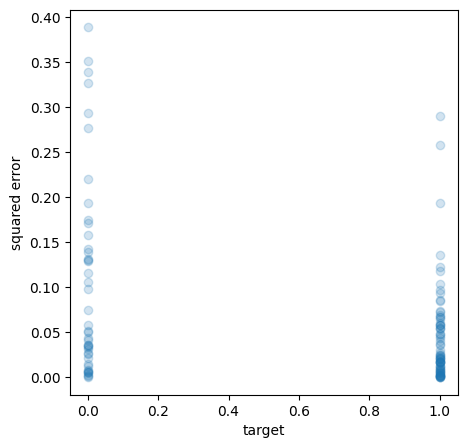

In [116]:
def plot_se(y, y_pred):
  plt.figure(figsize=(5,5))
  plt.scatter(y, (y-y_pred)**2, alpha=0.2)
  plt.xlabel("target")
  plt.ylabel("squared error")

plot_se(y_test, y_pred)
plt.show()

In [117]:
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np
from sklearn.metrics import mean_squared_error

def include_bias(X):
  return np.c_[np.ones(len(X)), X]

class LinearClassifier(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    Xb = include_bias(X)
    self.w = np.linalg.pinv(Xb) @ y
    return self
  def predict(self, X):
    Xb = include_bias(X)
    y_pred = Xb @ self.w
    return np.array(y_pred > 0.5, dtype=int)

model = LinearClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(mean_squared_error(y_test, y_pred))

0.06140350877192982


In [118]:
print(y_test[:6])
print(y_pred[:6])

[1 0 0 1 1 0]
[1 0 0 1 1 0]


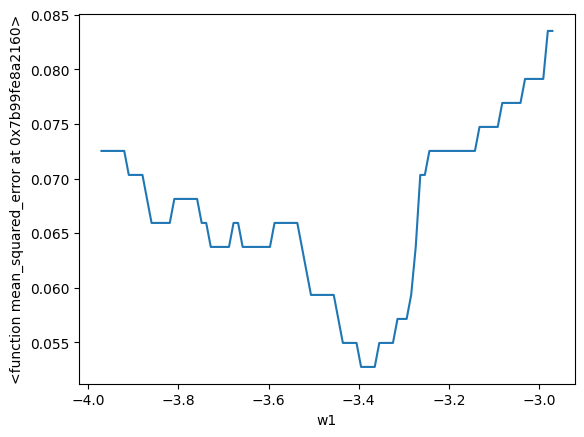

In [119]:
plot_metric_by_coef(model, X_train, y_train, coef_idx=1)

In [120]:
sum(y_test == y_pred)/len(y_test)

np.float64(0.9385964912280702)

In [121]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9385964912280702

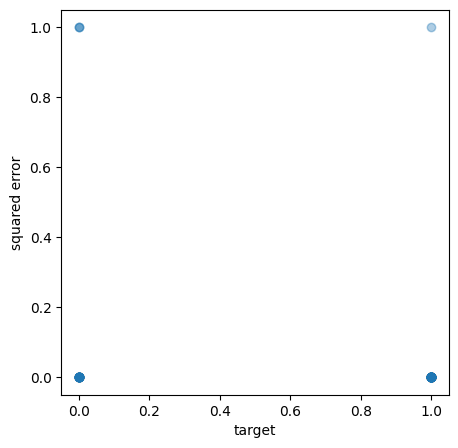

In [122]:
plot_se(y_test, y_pred)
plt.show()

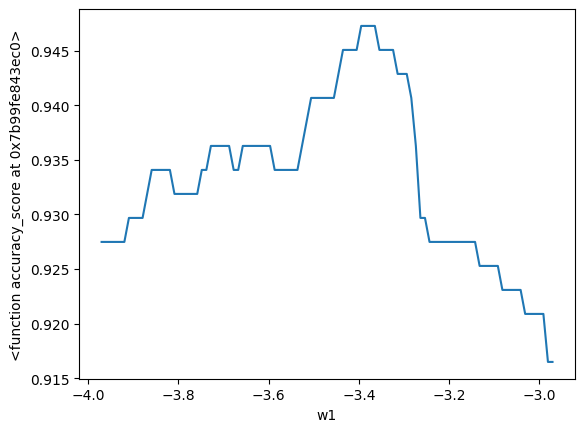

In [123]:
plot_metric_by_coef(model, X_train, y_train, coef_idx=1, metric=accuracy_score)